In [1]:
# CELL 1: Imports
import os
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from collections import Counter
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

# CELL 2: Data path and common files (matching YAMNET)
data_path = '/kaggle/input/datasets/tushaamagrawal/icbhi-2017-challenge/ICBHI_final_database'

total_files = os.listdir(data_path)
wav_files = [f for f in total_files if f.endswith(".wav")]
txt_files = [f for f in total_files if f.endswith(".txt")]

wav_set = set([f.replace(".wav", "") for f in wav_files])
txt_set = set([f.replace(".txt", "") for f in txt_files])
common_files = list(wav_set.intersection(txt_set))
print(f"Usable files: {len(common_files)}")

# Split exactly as in aero-yamnet notebook
train_files, test_files = train_test_split(common_files, test_size=0.2, random_state=42)
train_files, val_files   = train_test_split(train_files, test_size=0.2, random_state=42)

print(f"Train files: {len(train_files)} | Val files: {len(val_files)} | Test files: {len(test_files)}")



Usable files: 920
Train files: 588 | Val files: 148 | Test files: 184


In [2]:
def add_noise(signal, noise_factor=0.005):
    noise = np.random.randn(len(signal))
    return signal + noise_factor * noise

def time_shift(signal, shift_max=0.2):
    shift = int(np.random.uniform(-shift_max, shift_max) * len(signal))
    return np.roll(signal, shift)

def time_stretch(signal, rate=0.9):
    return librosa.effects.time_stretch(signal, rate)

def pitch_shift(signal, sr=16000, n_steps=1):
    return librosa.effects.pitch_shift(signal, sr=sr, n_steps=n_steps)

def augment_signal(signal, sr=16000):
    augmented = []
    augmented.append(signal)                     # original
    augmented.append(add_noise(signal))          # noise
    augmented.append(time_shift(signal))         # shift
    try:
        augmented.append(time_stretch(signal, rate=np.random.uniform(0.9, 1.1)))
    except:
        pass
    try:
        augmented.append(pitch_shift(signal, sr, n_steps=np.random.uniform(-1,1)))
    except:
        pass
    return augmented


In [3]:
def extract_audio_features(segment, sr=16000):
    segment = segment.astype(np.float32)
    # MFCCs
    mfccs = librosa.feature.mfcc(y=segment, sr=sr, n_mfcc=40)
    mfccs_mean = np.mean(mfccs.T, axis=0)
    mfccs_std  = np.std(mfccs.T, axis=0)
    # Spectral centroid & rolloff
    centroid = librosa.feature.spectral_centroid(y=segment, sr=sr)
    cent_mean = np.mean(centroid)
    rolloff = librosa.feature.spectral_rolloff(y=segment, sr=sr)
    roll_mean = np.mean(rolloff)
    # Zero crossing rate
    zcr = librosa.feature.zero_crossing_rate(segment)
    zcr_mean = np.mean(zcr)
    # Combine
    return np.hstack([mfccs_mean, mfccs_std, cent_mean, roll_mean, zcr_mean])

def get_label(crackle, wheeze):
    if crackle == 0 and wheeze == 0: return 0
    elif crackle == 1 and wheeze == 0: return 1
    elif crackle == 0 and wheeze == 1: return 2
    else: return 3

def build_segments(file_list, augment=False):
    """Extract segments and features. If augment=True, apply augmentation to each segment."""
    X = []
    y = []
    sr = 16000
    for file in file_list:
        wav_file = os.path.join(data_path, file + '.wav')
        txt_file = os.path.join(data_path, file + '.txt')
        if not os.path.exists(wav_file) or not os.path.exists(txt_file):
            continue
        audio, sr = librosa.load(wav_file, sr=sr)
        annotations = pd.read_csv(txt_file, sep='\t', names=['start', 'end', 'crackle', 'wheeze'])
        for _, row in annotations.iterrows():
            start = int(row['start'] * sr)
            end   = int(row['end'] * sr)
            segment = audio[start:end]
            if len(segment) < 1000:      # Same threshold as YAMNET
                continue
            label = get_label(row['crackle'], row['wheeze'])
            if augment:
                augmented_segments = augment_signal(segment, sr)
                for aug_seg in augmented_segments:
                    if len(aug_seg) >= 1000:
                        X.append(extract_audio_features(aug_seg, sr))
                        y.append(label)
            else:
                X.append(extract_audio_features(segment, sr))
                y.append(label)
    return np.array(X), np.array(y)

In [4]:

# CELL 5: Build train (with augmentation), validation and test sets
print("Building training set with augmentation...")
X_train, y_train = build_segments(train_files, augment=True)
print(f"Train features shape: {X_train.shape}")

print("Building validation set (no augmentation)...")
X_val, y_val = build_segments(val_files, augment=False)
print(f"Val features shape: {X_val.shape}")

print("Building test set (no augmentation)...")
X_test, y_test = build_segments(test_files, augment=False)
print(f"Test features shape: {X_test.shape}")

# CELL 6: SMOTE to balance training data
print("\nOriginal training class distribution:", dict(Counter(y_train)))
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)
print("After SMOTE:", dict(Counter(y_train_bal)))
print(f"Balanced train shape: {X_train_bal.shape}")

# CELL 7: Train XGBoost
xgb_model = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.0001,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softprob',
    eval_metric=['mlogloss', 'merror'],
    early_stopping_rounds=30,
    random_state=42,
    n_jobs=-1
)

print("\nTraining XGBoost...")
xgb_model.fit(
    X_train_bal, y_train_bal,
    eval_set=[(X_train_bal, y_train_bal), (X_val, y_val)],
    verbose=20
)


Building training set with augmentation...
Train features shape: (17760, 83)
Building validation set (no augmentation)...
Val features shape: (1048, 83)
Building test set (no augmentation)...
Test features shape: (1410, 83)

Original training class distribution: {np.int64(0): 9404, np.int64(2): 2332, np.int64(1): 4644, np.int64(3): 1380}
After SMOTE: {np.int64(0): 9404, np.int64(2): 9404, np.int64(1): 9404, np.int64(3): 9404}
Balanced train shape: (37616, 83)

Training XGBoost...
[0]	validation_0-mlogloss:1.38624	validation_0-merror:0.36048	validation_1-mlogloss:1.38627	validation_1-merror:0.59160
[20]	validation_0-mlogloss:1.38510	validation_0-merror:0.24742	validation_1-mlogloss:1.38576	validation_1-merror:0.52290
[38]	validation_0-mlogloss:1.38408	validation_0-merror:0.24269	validation_1-mlogloss:1.38532	validation_1-merror:0.52863


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=30,
              enable_categorical=False, eval_metric=['mlogloss', 'merror'],
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.0001, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=7, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=1000, n_jobs=-1,
              num_parallel_tree=None, ...)


 🚀 XGBoost: PERFORMANCE METRICS
Accuracy:      0.5184
Macro F1:      0.3924
Weighted F1:   0.5347
Precision:     0.5799
Recall:        0.5184
-----------------------------------

Classification Report:

              precision    recall  f1-score   support

      Normal       0.76      0.55      0.64       804
     Crackle       0.43      0.62      0.51       372
      Wheeze       0.25      0.29      0.27       142
        Both       0.13      0.18      0.16        92

    accuracy                           0.52      1410
   macro avg       0.39      0.41      0.39      1410
weighted avg       0.58      0.52      0.53      1410



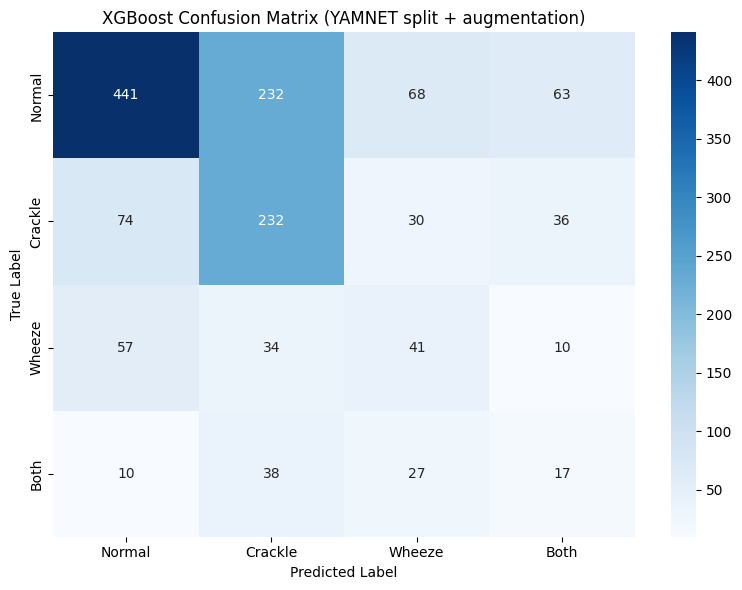


Model saved to /kaggle/working/xgboost_model.json


In [5]:
# CELL 8: Evaluation on test set
y_pred = xgb_model.predict(X_test)

class_names = ['Normal', 'Crackle', 'Wheeze', 'Both']
accuracy = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average='macro')
weighted_f1 = f1_score(y_test, y_pred, average='weighted')
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)

print("\n" + "="*35)
print(" 🚀 XGBoost: PERFORMANCE METRICS")
print("="*35)
print(f"Accuracy:      {accuracy:.4f}")
print(f"Macro F1:      {macro_f1:.4f}")
print(f"Weighted F1:   {weighted_f1:.4f}")
print(f"Precision:     {precision:.4f}")
print(f"Recall:        {recall:.4f}")
print("-"*35)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title("XGBoost Confusion Matrix (YAMNET split + augmentation)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

# CELL 9: Save model (optional)
model_path = '/kaggle/working/xgboost_model.json'
xgb_model.save_model(model_path)
print(f"\nModel saved to {model_path}")